In [3]:
# %% Cell 1: imports
import sys, torch, numpy as np
sys.path.append('..'); sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from backbones.backbones import get_resnet50, get_vit, get_clip
from img_prep.make_subset import load_stl10
from img_prep.transforms import to_common_224, resnet_normalize, vit_normalize, clip_normalize
from img_prep.adain import AdaINStyleTransfer
from img_prep.make_cue_conflicts import build_conflict_plan, CLASS_PAIRS
from evaluations.evaluate_bias import shape_texture_counts, extract_features_from_tensors
import open_clip, torch.nn as nn
import matplotlib.pyplot as plt

set_seed(6304)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
# %% Cell 2: load the 500-image subset
subset_ids = load_results("../results/subset_ids.json")
test_idx = subset_ids["test_subset_indices"]
test_ds = load_stl10(split='test')
class_names = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']

# pre-load all 500 images once as [0,1] 224x224 tensors
subset_imgs = torch.stack([to_common_224(test_ds[i][0]) for i in test_idx])
subset_labels = np.array([test_ds[i][1] for i in test_idx])
print(subset_imgs.shape, subset_labels.shape)

torch.Size([500, 3, 224, 224]) (500,)


In [5]:
# %% Cell 3: build the conflict plan (seeded, saved)
plan = build_conflict_plan(subset_labels, class_names, n_per_direction=26, seed=6304)
print(f"{len(plan)} planned conflicts")
save_results({"seed": 6304, "plan": plan}, "../results/cue_conflict_plan.json")

260 planned conflicts


In [6]:
# %% Cell 4: generate conflicts at both alphas, apply the rejection rule
adain = AdaINStyleTransfer("../../datasets/adain_weights/vgg_normalised.pth",
                            "../../datasets/adain_weights/decoder.pth", device=device)

content_batch = torch.stack([subset_imgs[p["content_pos"]] for p in plan])
style_batch   = torch.stack([subset_imgs[p["style_pos"]]   for p in plan])

generated = {}
for alpha in [0.7]:
    outs = []
    for i in range(0, len(plan), 32):
        outs.append(adain(content_batch[i:i+32], style_batch[i:i+32], alpha=alpha).cpu())
    generated[alpha] = torch.cat(outs)
    print(f"alpha={alpha}: {len(generated[alpha])} conflicts generated")

alpha=0.7: 260 conflicts generated


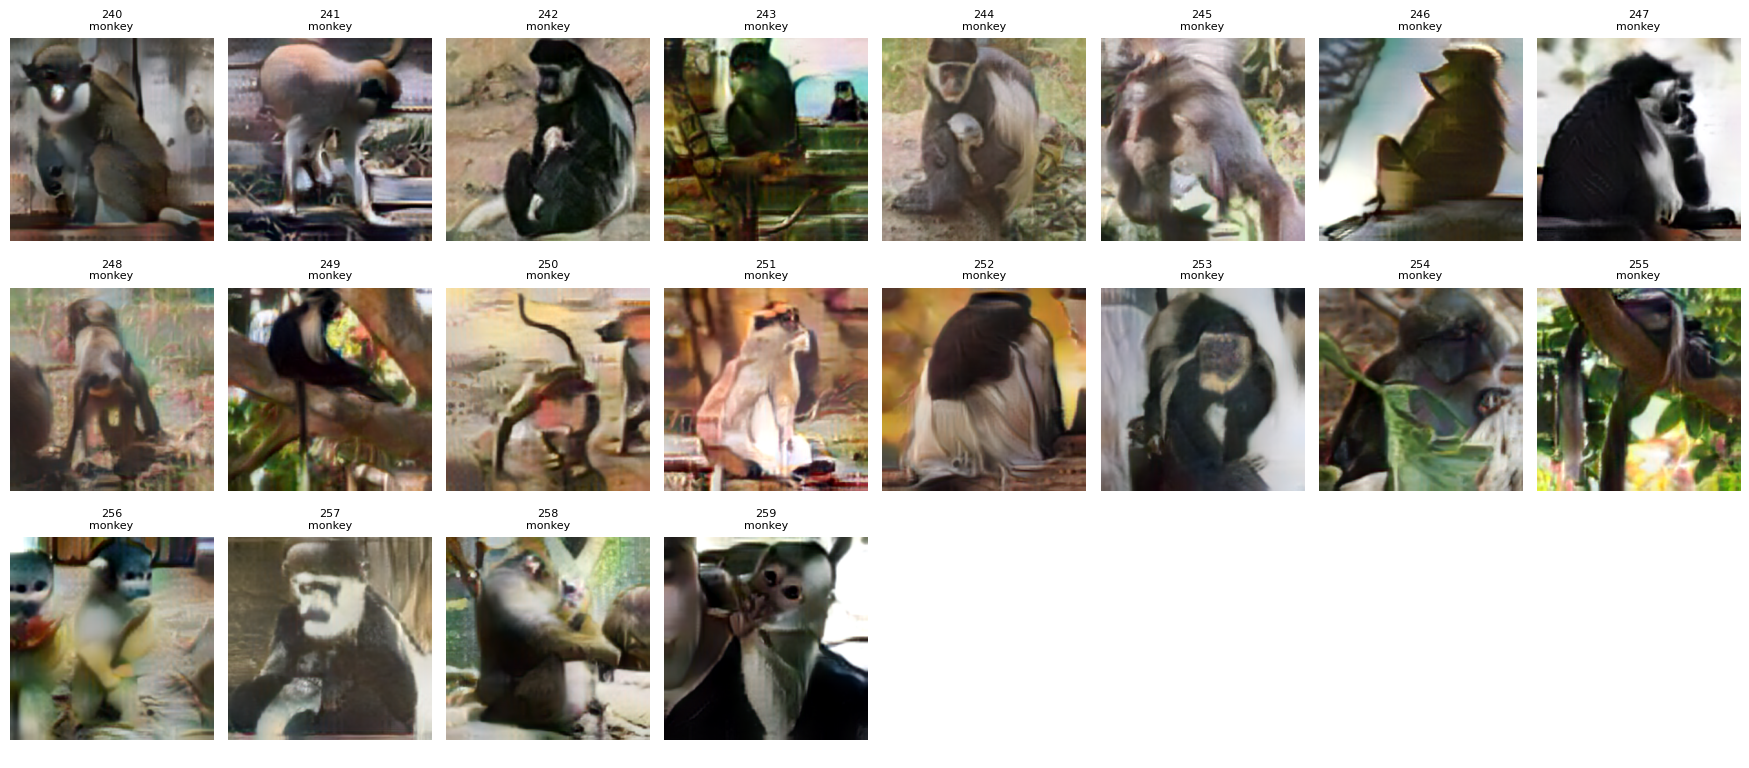

In [7]:
# %% Cell 5: paginated viewer for manual inspection
def show_page(alpha, page, per_page=40, cols=8):
    imgs = generated[alpha]
    start = page * per_page
    idxs = list(range(start, min(start + per_page, len(imgs))))
    rows = (len(idxs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.6 * rows))
    for ax, i in zip(axes.flat, idxs):
        ax.imshow(imgs[i].permute(1, 2, 0).numpy())
        p = plan[i]
        ax.set_title(f"{i}\n{class_names[p['shape_label']]}", fontsize=8)
        ax.axis('off')
    for ax in axes.flat[len(idxs):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_page(0.7, 6)

In [8]:
# %% Cell 5b: record visual rejections
REJECTED = [8, 16, 21, 31, 34, 35, 39,
            41, 43, 48, 65, 79,
            83, 85, 86, 101, 107, 108, 113,
            128, 133, 134, 138, 142, 155,
            166, 177, 183, 187,
            201, 202, 203, 207]

keep_mask = np.array([i not in set(REJECTED) for i in range(len(plan))])
print(f"generated {len(plan)}, rejected {len(REJECTED)}, kept {keep_mask.sum()}")

save_results({
    "alpha": 0.7,
    "n_generated": len(plan),
    "n_rejected": len(REJECTED),
    "n_accepted": int(keep_mask.sum()),
    "rejected_indices": REJECTED,
    "criterion": "visual inspection: content object no longer recognisable"
}, "../results/cue_conflict_rejections.json")

generated 260, rejected 33, kept 227


In [9]:
# %% Cell 6: evaluate all four models on the accepted conflicts
resnet, _ = get_resnet50(); vit, _ = get_vit(); clip_model, _ = get_clip()
tokenizer = open_clip.get_tokenizer('ViT-B-32')

def load_head(name, in_dim):
    head = nn.Linear(in_dim, 10).to(device)
    head.load_state_dict(torch.load(f"../../datasets/cache/{name}_head.pth", map_location=device))
    head.eval(); return head

heads = {"resnet50": load_head("resnet50", 2048),
         "vit_b16": load_head("vit_b16", 768),
         "clip_head": load_head("clip_head", 512)}

backbones_info = [("resnet50", resnet, resnet_normalize, "resnet_or_vit"),
                  ("vit_b16", vit, vit_normalize, "resnet_or_vit"),
                  ("clip", clip_model, clip_normalize, "clip")]

ALPHA = 0.7
keep_t = torch.tensor(keep_mask)
imgs_kept = generated[ALPHA][keep_t]
plan_kept = [p for p, k in zip(plan, keep_mask) if k]
shape_labels = np.array([p["shape_label"] for p in plan_kept])
texture_labels = np.array([p["texture_label"] for p in plan_kept])

results = {"step": "shape_texture", "seed": 6304, "alpha": ALPHA,
           "n_generated": len(plan), "n_rejected": int((~keep_mask).sum()),
           "n_accepted": int(keep_mask.sum()), "models": {}}

all_preds = {}   # kept for the example analysis in Cell 8

for name, model, norm_fn, mtype in backbones_info:
    feats = extract_features_from_tensors(model, imgs_kept, norm_fn, model_type=mtype, device=device)

    if name == "clip":
        with torch.no_grad():
            preds = heads["clip_head"](torch.tensor(feats, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
        all_preds["clip_head"] = preds
        results["models"]["clip_head"] = shape_texture_counts(preds, shape_labels, texture_labels)

        batch = torch.stack([clip_normalize(x) for x in imgs_kept]).to(device)
        with torch.no_grad():
            tf_ = clip_model.encode_text(tokenizer([f"a photo of a {c}." for c in class_names]).to(device))
            tf_ = tf_ / tf_.norm(dim=-1, keepdim=True)
            imf = clip_model.encode_image(batch)
            imf = imf / imf.norm(dim=-1, keepdim=True)
            zs_preds = (clip_model.logit_scale.exp() * imf @ tf_.T).argmax(1).cpu().numpy()
        all_preds["clip_zeroshot"] = zs_preds
        results["models"]["clip_zeroshot"] = shape_texture_counts(zs_preds, shape_labels, texture_labels)
        del batch; torch.cuda.empty_cache()
    else:
        with torch.no_grad():
            preds = heads[name](torch.tensor(feats, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
        all_preds[name] = preds
        results["models"][name] = shape_texture_counts(preds, shape_labels, texture_labels)
    del feats; torch.cuda.empty_cache()

print(f"alpha={ALPHA}, {results['n_accepted']} accepted of {results['n_generated']}")
for m, r in results["models"].items():
    print(f"  {m}: shape_bias {r['shape_bias_pct']:.1f}%  coverage {r['coverage_pct']:.1f}%  "
          f"({r['n_shape']}/{r['n_texture']}/{r['n_other']})")

alpha=0.7, 227 accepted of 260
  resnet50: shape_bias 87.9%  coverage 61.7%  (123/17/87)
  vit_b16: shape_bias 98.3%  coverage 79.3%  (177/3/47)
  clip_head: shape_bias 98.8%  coverage 74.4%  (167/2/58)
  clip_zeroshot: shape_bias 98.9%  coverage 83.3%  (187/2/38)


In [12]:
# %% Cell 7: save
save_results(results, "../results/shape_texture.json")
print(results)

{'step': 'shape_texture', 'seed': 6304, 'alpha': 0.7, 'n_generated': 260, 'n_rejected': 33, 'n_accepted': 227, 'models': {'resnet50': {'n_shape': 123, 'n_texture': 17, 'n_other': 87, 'n_total': 227, 'shape_bias_pct': 87.85714285714286, 'coverage_pct': 61.67400881057269}, 'vit_b16': {'n_shape': 177, 'n_texture': 3, 'n_other': 47, 'n_total': 227, 'shape_bias_pct': 98.33333333333333, 'coverage_pct': 79.29515418502203}, 'clip_head': {'n_shape': 167, 'n_texture': 2, 'n_other': 58, 'n_total': 227, 'shape_bias_pct': 98.81656804733728, 'coverage_pct': 74.44933920704845}, 'clip_zeroshot': {'n_shape': 187, 'n_texture': 2, 'n_other': 38, 'n_total': 227, 'shape_bias_pct': 98.94179894179894, 'coverage_pct': 83.25991189427313}}}


In [13]:
# %% Cell 8: informative cases
model_order = ["resnet50", "vit_b16", "clip_head", "clip_zeroshot"]

def verdict(pred, s, t):
    if pred == s: return "shape"
    if pred == t: return "texture"
    return "other"

cases = {"split_shape_vs_texture": [], "all_texture": [], "all_shape": [], "all_other": []}
for i in range(len(plan_kept)):
    v = [verdict(all_preds[m][i], shape_labels[i], texture_labels[i]) for m in model_order]
    if "shape" in v and "texture" in v:
        cases["split_shape_vs_texture"].append(i)
    elif all(x == "texture" for x in v):
        cases["all_texture"].append(i)
    elif all(x == "shape" for x in v):
        cases["all_shape"].append(i)
    elif all(x == "other" for x in v):
        cases["all_other"].append(i)

for k, v in cases.items():
    print(f"{k}: {len(v)} images")

# where do the "other" predictions actually land? feeds the semantic-adjacency point
import collections
other_preds = collections.Counter()
for i in range(len(plan_kept)):
    for m in model_order:
        if verdict(all_preds[m][i], shape_labels[i], texture_labels[i]) == "other":
            other_preds[class_names[all_preds[m][i]]] += 1
print("\nclasses receiving 'other' predictions:", other_preds.most_common())

split_shape_vs_texture: 16 images
all_texture: 0 images
all_shape: 93 images
all_other: 10 images

classes receiving 'other' predictions: [('bird', 72), ('truck', 41), ('deer', 24), ('ship', 18), ('dog', 17), ('car', 15), ('horse', 13), ('airplane', 13), ('cat', 10), ('monkey', 7)]


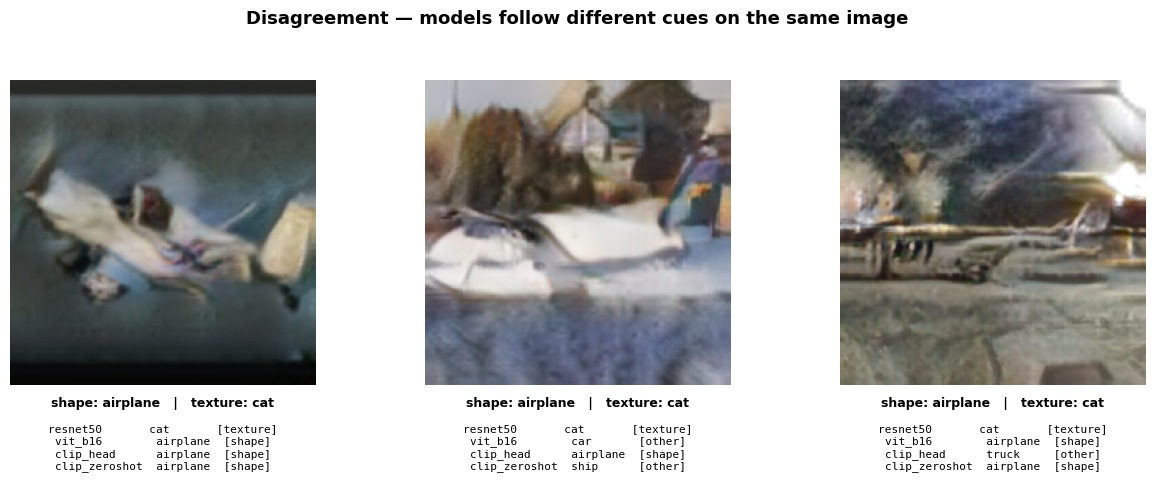

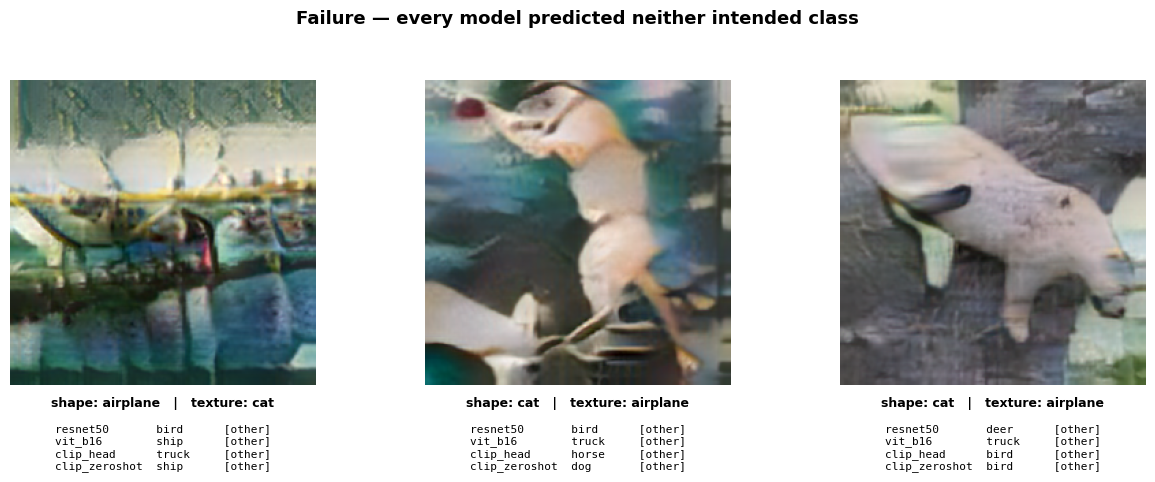

In [14]:
# %% Cell 9: example figure
def show_examples(indices, title, n=3, save_name=None):
    indices = indices[:n]
    if not indices:
        print(f"(no examples for: {title})"); return []
    fig, axes = plt.subplots(1, len(indices), figsize=(4.2 * len(indices), 5.4))
    if len(indices) == 1: axes = [axes]
    records = []
    for ax, i in zip(axes, indices):
        ax.imshow(imgs_kept[i].permute(1, 2, 0).numpy()); ax.axis('off')
        header = f"shape: {class_names[shape_labels[i]]}   |   texture: {class_names[texture_labels[i]]}"
        rows, rec = [], {"shape_class": class_names[shape_labels[i]],
                          "texture_class": class_names[texture_labels[i]], "predictions": {}}
        for m in model_order:
            pr = all_preds[m][i]; v = verdict(pr, shape_labels[i], texture_labels[i])
            rows.append(f"{m:<14} {class_names[pr]:<9} [{v}]")
            rec["predictions"][m] = {"predicted": class_names[pr], "verdict": v}
        ax.text(0.5, -0.04, header, transform=ax.transAxes, ha='center', va='top',
                fontsize=9, fontweight='bold')
        ax.text(0.5, -0.13, "\n".join(rows), transform=ax.transAxes, ha='center', va='top',
                fontsize=8, family='monospace')
        records.append(rec)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.22, 1, 0.94])
    if save_name:
        fig.savefig(f"../../report/figures/{save_name}.png", dpi=200, bbox_inches='tight')
    plt.show()
    return records

examples = {}
examples["disagreement"] = show_examples(cases["split_shape_vs_texture"],
    "Disagreement — models follow different cues on the same image",
    save_name="cue_conflict_disagreement")
examples["all_other"] = show_examples(cases["all_other"],
    "Failure — every model predicted neither intended class",
    save_name="cue_conflict_failures")

save_results({"alpha": ALPHA, "examples": examples}, "../results/cue_conflict_examples.json")